1. Постановка задачи

Датасет содержит записи о розничных заказах интернет-магазина SuperStore за 2011–2014 гг. Каждая строка — позиция заказа: клиент, сегмент, категория товара, дата заказа и отгрузки, объём продаж, количество, скидка, прибыль, стоимость доставки и приоритет заказа.

Заказчик: отдел продаж и маркетинга компании; также может использоваться руководством для оценки эффективности.

Задачи:
1. Сегментация клиентов по объёму и прибыльности заказов
2. Поиск аномалий — убыточные заказы с большой скидкой.
3. Описательная аналитика — какие категории и приоритеты дают наибольшую прибыль.
4. Прогнозирование прибыли по параметрам заказа.

2. Паспорт датасета

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Настройки отображения
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

URL = "https://raw.githubusercontent.com/viktoria24nar/lab1/main/SuperStoreOrders.csv"

df = pd.read_csv(URL, thousands=",")

print("Данные успешно загружены.")
print(f"Размер датасета: {df.shape[0]} строк * {df.shape[1]} столбцов\n")

df.head()

Данные успешно загружены.
Размер датасета: 51290 строк * 12 столбцов



,order_id,order_date,ship_date,customer_name,segment,category,sales,quantity,discount,profit,shipping_cost,order_priority
0,AG-2011-2040,1/1/2011,6/1/2011,Toby Braunhardt,Consumer,Office Supplies,408,2,0.0,106.140,35.46,Medium
1,IN-2011-47883,1/1/2011,8/1/2011,Joseph Holt,Consumer,Office Supplies,120,3,0.1,36.036,9.72,Medium
2,HU-2011-1220,1/1/2011,5/1/2011,Annie Thurman,Consumer,Office Supplies,66,4,0.0,29.640,8.17,High
3,IT-2011-3647632,1/1/2011,5/1/2011,Eugene Moren,Home Office,Office Supplies,45,3,0.5,-26.055,4.82,High
4,IN-2011-47883,1/1/2011,8/1/2011,Joseph Holt,Consumer,Furniture,114,5,0.1,37.770,4.70,Medium


In [91]:
meaning = {
    "order_id":       "Идентификатор заказа",
    "order_date":     "Дата оформления заказа",
    "ship_date":      "Дата отгрузки заказа",
    "customer_name":  "Имя клиента",
    "segment":        "Клиентский сегмент (Consumer / Corporate / Home Office)",
    "category":       "Категория товара (Office Supplies / Furniture / Technology)",
    "sales":          "Объём продаж по позиции",
    "quantity":       "Количество единиц товара",
    "discount":       "Скидка (доля от 0 до 1)",
    "profit":         "Прибыль по позиции",
    "shipping_cost":  "Стоимость доставки",
    "order_priority": "Приоритет заказа (Low / Medium / High / Critical)",
}

passport = pd.DataFrame({
    "тип в pandas":         df.dtypes.astype(str),
    "предполагаемый смысл": [meaning.get(c, "—") for c in df.columns],
    "пример значения":      [df[c].dropna().iloc[0] for c in df.columns],
    "уникальных значений":  df.nunique(),
})

passport

,тип в pandas,предполагаемый смысл,пример значения,уникальных значений
order_id,object,Идентификатор заказа,AG-2011-2040,25035
order_date,object,Дата оформления заказа,1/1/2011,1430
ship_date,object,Дата отгрузки заказа,6/1/2011,1464
customer_name,object,Имя клиента,Toby Braunhardt,795
segment,object,Клиентский сегмент (Consumer / Corporate / Hom...,Consumer,3
category,object,Категория товара (Office Supplies / Furniture ...,Office Supplies,3
sales,int64,Объём продаж по позиции,408,2246
quantity,int64,Количество единиц товара,2,14
discount,float64,Скидка (доля от 0 до 1),0.0,27
profit,float64,Прибыль по позиции,106.14,24575


В датасете 12 признаков: 5 числовых (`sales`, `quantity`, `discount`, `profit`, `shipping_cost`), 5 категориальных (`order_id`, `customer_name`, `segment`, `category`, `order_priority`) и 2 временных (`order_date`, `ship_date`).
- Столбец `order_id` содержит меньше уникальных значений, чем всего строк, — значит, один заказ может включать несколько позиций.
- Даты пока имеют тип `object` (строки), их нужно преобразовать в `datetime64`.



In [92]:
# Даты записаны в формате Д/М/Г
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True, errors="coerce")
df["ship_date"]  = pd.to_datetime(df["ship_date"],  dayfirst=True, errors="coerce")

print("Типы после преобразования:\n")
print(df.dtypes)

print("\nПропуски, возникшие при изменении дат:")
print(df[["order_date", "ship_date"]].isna().sum())

print("\nДиапазон дат заказов:",
      df["order_date"].min().date(), "—", df["order_date"].max().date())

Типы после преобразования:

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
customer_name             object
segment                   object
category                  object
sales                      int64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
dtype: object

Пропуски, возникшие при изменении дат:
order_date    0
ship_date     0
dtype: int64

Диапазон дат заказов: 2011-01-01 — 2014-12-31


3. Аудит качества данных

3.1. Пропуски

In [93]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)

miss_df = pd.DataFrame({
    "количество пропусков": missing,
    "доля, %":              missing_pct,
}).sort_values("количество пропусков", ascending=False)

miss_df

,количество пропусков,"доля, %"
order_id,0,0.0
order_date,0,0.0
ship_date,0,0.0
customer_name,0,0.0
segment,0,0.0
category,0,0.0
sales,0,0.0
quantity,0,0.0
discount,0,0.0
profit,0,0.0


Вывод. Пропусков ни в одном из 12 столбцов не обнаружено — доля пропусков равна 0% по каждому признаку. Это означает, что датасет прошёл предварительную очистку ещё до публикации, и на этапе анализа не требуется удаление строк.

3.2. Дубликаты

In [94]:
full_dup = df.duplicated().sum()
id_dup   = df["order_id"].duplicated().sum()

print("Полных дубликатов строк:", full_dup)
print("Повторяющихся order_id:", id_dup)
print("Уникальных order_id:", df["order_id"].nunique())
print("Всего строк:", len(df))

Полных дубликатов строк: 0
Повторяющихся order_id: 26255
Уникальных order_id: 25035
Всего строк: 51290


Вывод.*
Полных дубликатов строк — 0, то есть ни одна запись не повторяется целиком.

Повторяющихся `order_id` — 26 255 при 25 035 уникальных заказах и 51 290 строках. Это не ошибка данных, а нормальная структура: один заказ содержит несколько позиций.

Что это значит для дальнейшего анализа.  
- Удалять повторяющиеся `order_id`нельзя — иначе потеряется большая часть информации о позициях.
- Если анализ проводится на уровне заказов (например, средний чек), данные нужно агрегировать по `order_id`: сумма `sales`, сумма `profit`, число позиций и т. д.

3.3. Типические проблемы значений

In [95]:
num_cols = ["sales", "quantity", "discount", "profit", "shipping_cost"]
df[num_cols].describe().round(2)

,sales,quantity,discount,profit,shipping_cost
count,51290.00,51290.00,51290.00,51290.00,51290.00
mean,246.50,3.48,0.14,28.64,26.38
std,487.57,2.28,0.21,174.42,57.30
min,0.00,1.00,0.00,-6599.98,0.00
25%,31.00,2.00,0.00,0.00,2.61
50%,85.00,3.00,0.00,9.24,7.79
75%,251.00,5.00,0.20,36.81,24.45
max,22638.00,14.00,0.85,8399.98,933.57


Вывод по числовым признакам.

- `sales`: минимум 0 — есть позиции с нулевой суммой продаж. Это потенциальная аномалия: продажа не может стоить 0. Такие строки нужно отдельно посмотреть.
- `quantity`: диапазон 1–14, отрицательных и нулевых нет — данные корректны.
- `discount`: диапазон 0–0.85, среднее 0.14. Максимальная скидка выше типичных 0.8 — стоит проверить, обосновано ли это.
- `profit`: диапазон от −6599.98 до 8399.98, стандартное отклонение 174.42 сильно превышает среднее 28.64. Это говорит о крайне неоднородном распределении.
- Ключевое наблюдение: Q1 (25-й процентиль) прибыли равен 0. Это значит, что не менее 25% всех позиций заказа убыточны или безубыточны. Это серьёзный сигнал для бизнеса и требует отдельного анализа.
- `shipping_cost`: минимум 0 — есть позиции с бесплатной доставкой, что тоже нужно проверить.

Общие выводы для отчёта:
1. Данные в целом корректны по диапазонам.
2. Основные «красные флаги»: нулевые продажи, максимум скидки 0.85, разброс прибыли и доля убыточных позиций ≥ 25%.

Подозрительные значения

In [96]:
print("sales <= 0:",              (df["sales"] <= 0).sum())
print("quantity <= 0:",           (df["quantity"] <= 0).sum())
print("discount вне [0, 1]:",     ((df["discount"] < 0) | (df["discount"] > 1)).sum())
print("profit < 0:",              (df["profit"] < 0).sum(),
      f"({(df['profit'] < 0).mean()*100:.2f}% строк)")
print("ship_date < order_date:",  (df["ship_date"] < df["order_date"]).sum())
print("shipping_cost < 0:",       (df["shipping_cost"] < 0).sum())

sales <= 0: 1
quantity <= 0: 0
discount вне [0, 1]: 0
profit < 0: 12543 (24.46% строк)
ship_date < order_date: 0
shipping_cost < 0: 0


Вывод по типическим проблемам значений.

- `sales <= 0` — 1 строка. Единичный случай с нулевой суммой продаж. Позиция с продажей за 0 — подозрительная запись, её стоит либо удалить, либо пометить отдельно.
- `quantity <= 0` — 0. Количество всегда положительное, данные корректны.
- `discount` вне [0, 1] — 0. Все скидки в допустимом диапазоне.
- `profit < 0` — 12 543 строки, то есть 24.46%. Каждая четвёртая позиция заказа убыточна. Это главная проблема качества и бизнес-логики датасета. Сами по себе отрицательные значения не являются «грязью» — это реальные сделки, но их доля настолько велика, что она требует отдельного анализа.
- `ship_date < order_date` — 0. Даты согласованы: ни один заказ не отгружен раньше оформления.
- `shipping_cost < 0` — 0. Стоимость доставки всегда неотрицательная.


Категориальные признаки

In [97]:
for col in ["segment", "category", "order_priority"]:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))
    # проверка на скрытые пробелы по краям
    s = df[col].dropna().astype(str)
    dirty = s[s != s.str.strip()].unique()
    if len(dirty):
        print("  ! значения с пробелами:", dirty)


=== segment ===
segment
Consumer       26518
Corporate      15429
Home Office     9343
Name: count, dtype: int64

=== category ===
category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64

=== order_priority ===
order_priority
Medium      29433
High        15501
Critical     3932
Low          2424
Name: count, dtype: int64


Все три категориальных столбца содержат только ожидаемые значения, без опечаток, разного регистра и лишних пробелов по краям

3.4. Выбросы

Для поиска выбросов применим метод межквартильного размаха (IQR) к двум числовым признакам: `profit` и `sales`. Значения, выходящие за границы `[Q1 − 1.5·IQR; Q3 + 1.5·IQR]`, считаются выбросами.

In [98]:
def iqr_outliers(series, name):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < low) | (series > high)
    n = mask.sum()
    print(f"{name}:")
    print(f"  Q1 = {q1:.2f}, Q3 = {q3:.2f}, IQR = {iqr:.2f}")
    print(f"  границы выбросов: [{low:.2f}; {high:.2f}]")
    print(f"  выбросов: {n} ({n / len(series) * 100:.2f}%)\n")
    return mask

mask_profit = iqr_outliers(df["profit"], "profit")
mask_sales  = iqr_outliers(df["sales"],  "sales")

profit:
  Q1 = 0.00, Q3 = 36.81, IQR = 36.81
  границы выбросов: [-55.22; 92.03]
  выбросов: 9755 (19.02%)

sales:
  Q1 = 31.00, Q3 = 251.00, IQR = 220.00
  границы выбросов: [-299.00; 581.00]
  выбросов: 5655 (11.03%)



In [99]:
from scipy import stats

z_profit = np.abs(stats.zscore(df["profit"]))
z_sales  = np.abs(stats.zscore(df["sales"]))

# Классический порог |z| > 3
out_z_profit = z_profit > 3
out_z_sales  = z_sales  > 3

print(f"profit: выбросов по z-score (|z|>3): {out_z_profit.sum()} "
      f"({out_z_profit.mean()*100:.2f}%)")
print(f"sales:  выбросов по z-score (|z|>3): {out_z_sales.sum()} "
      f"({out_z_sales.mean()*100:.2f}%)")


profit: выбросов по z-score (|z|>3): 866 (1.69%)
sales:  выбросов по z-score (|z|>3): 1019 (1.99%)


Мы применили два подхода к одним и тем же числовым признакам:

- IQR (межквартильный размах) — устойчив к скошенным распределениям, опирается на медиану и квартили.
- z-score (отклонение от среднего в единицах стандартного отклонения, порог |z| > 3) — корректен только для распределений, близких к нормальному.

Почему результаты различаются.
Оба распределения — `profit` и `sales` — сильно скошены вправо и имеют тяжёлые хвосты. Из-за этого стандартное отклонение завышено самими выбросами, и порог |z| > 3 отсекает лишь самые экстремальные точки. IQR, наоборот, опирается на медиану и квартили, которые не зависят от крайних значений, поэтому находит больше отклонений — и для данной задачи это правильнее.

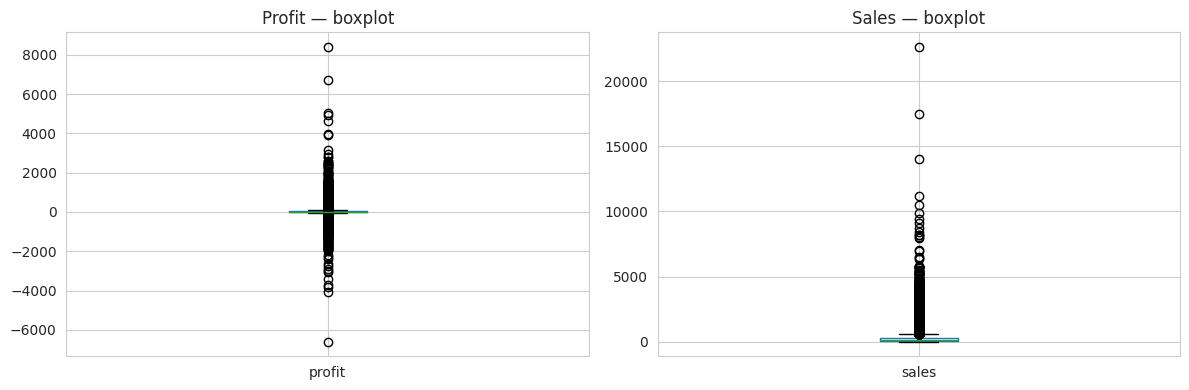

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.boxplot(column="profit", ax=axes[0]); axes[0].set_title("Profit — boxplot")
df.boxplot(column="sales",  ax=axes[1]); axes[1].set_title("Sales — boxplot")
plt.tight_layout()
plt.show()

У `profit` хвост выбросов тянется в обе стороны — от −6 600 до +8 400, что отражает наличие как глубоко убыточных, так и очень прибыльных сделок. У `sales` выбросы идут только вверх, до 22 638 — это крупные оптовые заказы.

4. Мини-EDA (разведочный анализ)

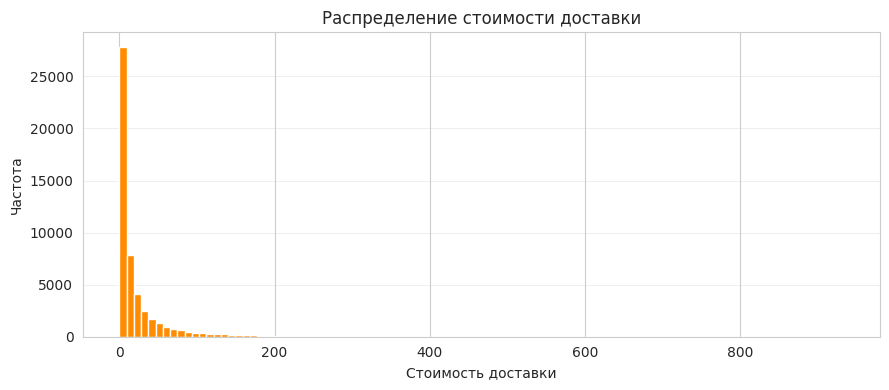

In [101]:
plt.figure(figsize=(9, 4))
df["shipping_cost"].hist(bins=100, color="darkorange", edgecolor="white")
plt.title("Распределение стоимости доставки")
plt.xlabel("Стоимость доставки")
plt.ylabel("Частота")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Что видно.** Распределение стоимости доставки ярко выражено правостороннее: основная масса заказов имеет низкую доставку (пик около 0–10, затем быстрый спад), а редкие крупные значения тянутся до 933.

**Гипотезы.** Высокая стоимость доставки связана с крупными заказами — большим `quantity` или высокой `sales`; вероятно, это оптовые и корпоративные сделки с дорогой логистикой.

**Вопросы.** Чем объясняются позиции с нулевой стоимостью доставки — промо-акцией или ошибкой учёта? Не съедает ли дорогая доставка маржу у крупных сделок?

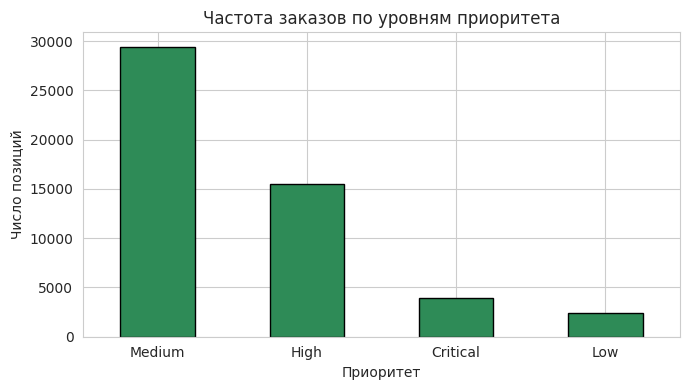

In [102]:
plt.figure(figsize=(7, 4))
df["order_priority"].value_counts().plot(kind="bar", color="seagreen", edgecolor="black")
plt.title("Частота заказов по уровням приоритета")
plt.xlabel("Приоритет")
plt.ylabel("Число позиций")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Что видно.** Распределение заказов по приоритетам крайне неравномерно. Более половины всех заказов имеют средний приоритет, а крайние уровни (Low и Critical) встречаются в разы реже.

**Гипотезы.** Компания, вероятно, использует Medium как приоритет по умолчанию; Critical может присваиваться срочным или крупным заказам, а Low — отложенным. Дисбаланс, скорее всего, отражает реальную бизнес-логику, а не ошибку данных.

**Вопросы.** Связан ли приоритет с прибылью и скидкой? Не скрывается ли под Medium основная доля убыточных сделок, и если да, стоит ли пересмотреть правила присвоения приоритета?

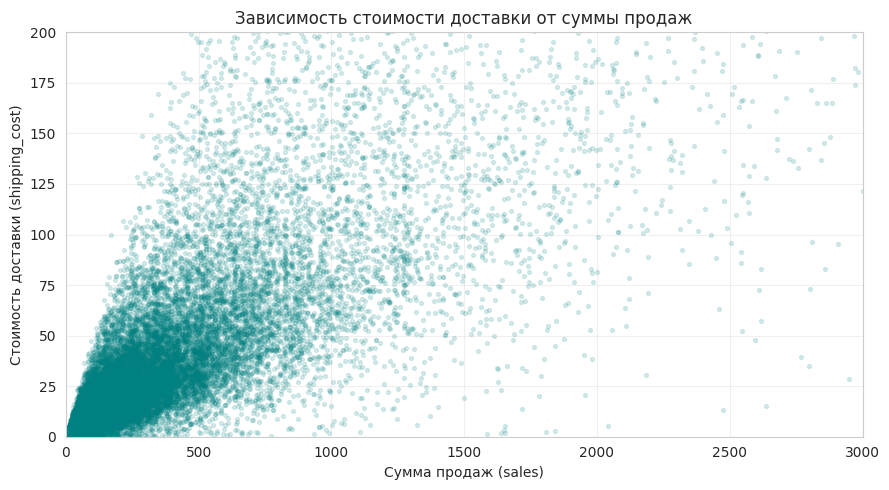

In [103]:
plt.figure(figsize=(9, 5))
plt.scatter(df["sales"], df["shipping_cost"], alpha=0.15, s=8, color="teal")
plt.title("Зависимость стоимости доставки от суммы продаж")
plt.xlabel("Сумма продаж (sales)")
plt.ylabel("Стоимость доставки (shipping_cost)")
plt.xlim(0, 3000)
plt.ylim(0, 200)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Что видно: Основная масса точек — в левом нижнем углу; с ростом продаж доставка в среднем дороже, но разброс резко растёт, есть точки с нулевой доставкой.

Гипотезы: Стоимость доставки зависит не только от суммы, но и от веса/габаритов/удалённости; нулевая доставка — бесплатная от порога или самовывоз.

Вопросы: Высокая доставка при малых продажах — аномалия или реальность?

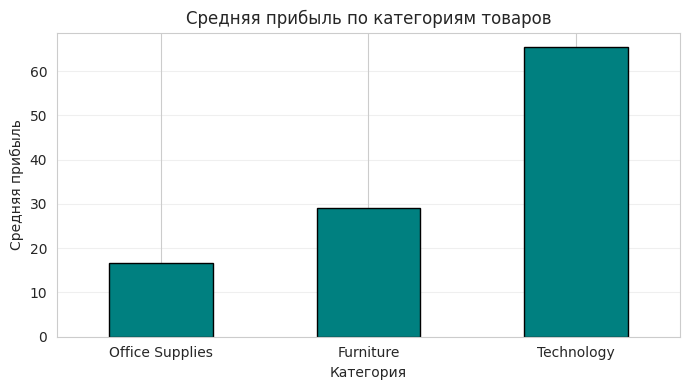

In [104]:
plt.figure(figsize=(7, 4))
df.groupby("category")["profit"].mean().sort_values().plot(
    kind="bar", color="teal", edgecolor="black"
)
plt.title("Средняя прибыль по категориям товаров")
plt.xlabel("Категория")
plt.ylabel("Средняя прибыль")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Что видно: Самая высокая средняя прибыль у категории Technology, средняя — у Furniture, самая низкая — у Office Supplies.

Гипотезы: Техника имеет высокую маржинальность. Низкая прибыль канцтоваров может компенсироваться большим объемом продаж, а мебель может иметь высокие издержки на логистику.

Вопросы: Это средняя прибыль с одного товара или с заказа? Нет ли крупных выбросов, искажающих среднее? Стоит ли увеличивать долю техники в ассортименте?